##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
!pip -q install --upgrade --force-reinstall "protobuf>=5.26.1,<6" "tensorflow==2.19.0" "tf-keras==2.19.0" "keras-cv"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 114.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 120.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 74.6 MB/

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

...

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.UYIQZ4_5.0.0/voc-train.tfrecord*...:   0%|          | …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.UYIQZ4_5.0.0/voc-validation.tfrecord*...:   0%|       …

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2012/5.0.0. Subsequent calls will reuse this data.
Loaded dataset: voc/2012
Selected 5 VOC2012 images for: ['aeroplane', 'bus', 'cat', 'dog', 'train']


Batch check -> images: 5 , preds: 5


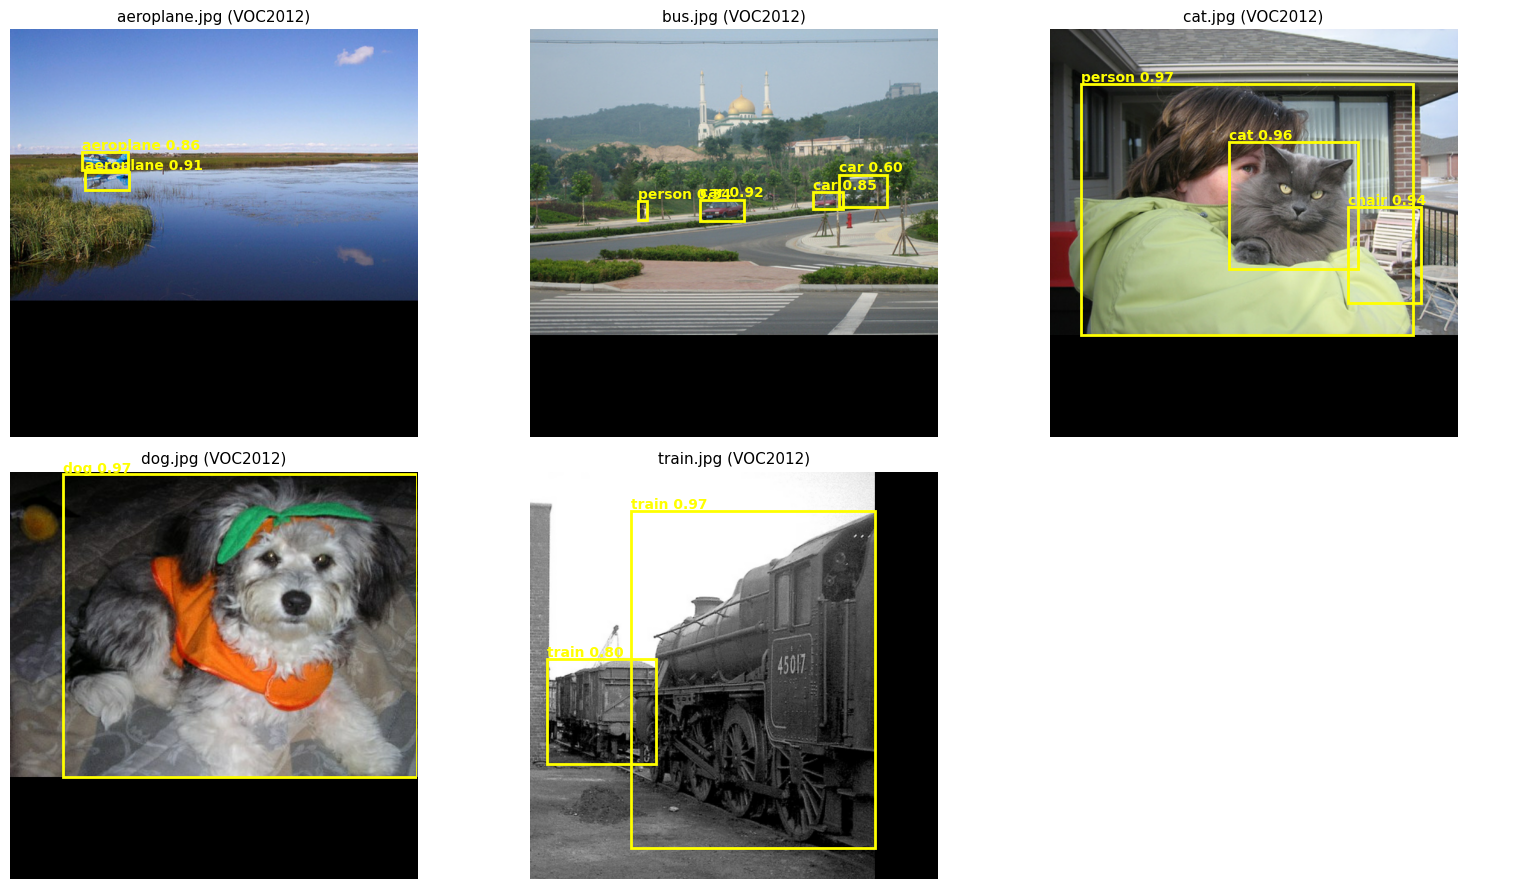

,Image File,GT objects (VOC2012),Detected correctly,Missed (GT only),Incorrect (Pred only),Top detections (>=0.25)
0,aeroplane.jpg,aeroplane,aeroplane,None,None,"aeroplane(0.91), aeroplane(0.86)"
1,bus.jpg,"bus, car, motorbike, person","car, person","bus, motorbike",None,"car(0.92), car(0.85), car(0.60)"
2,cat.jpg,"cat, chair, person","cat, chair, person",None,None,"person(0.97), cat(0.96), chair(0.94)"
3,dog.jpg,dog,dog,None,None,dog(0.97)
4,train.jpg,train,train,None,None,"train(0.97), train(0.80)"


In [ ]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
import keras_cv
from tensorflow import keras


try:
    import tensorflow_datasets as tfds
except ImportError:
    
    !pip -q install tensorflow-datasets
    import tensorflow_datasets as tfds

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

# Pascal VOC classes (20)
VOC_CLASSES = [
    "aeroplane","bicycle","bird","boat","bottle","bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person","pottedplant","sheep","sofa","train","tvmonitor"
]

# ---------------------------------------------------------
# 1) Load YOLOv8 detector (Pascal VOC preset) from KerasCV
# ---------------------------------------------------------
detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)

# ---------------------------------------------------------
# 2) Load 5 images from Pascal VOC 2012 dataset (TFDS)
#    Pick 5 different target classes.
# ---------------------------------------------------------
TARGET_CLASSES = ["aeroplane", "bus", "cat", "dog", "train"]
target_ids = {VOC_CLASSES.index(c) for c in TARGET_CLASSES}


ds = None
for name in ["voc/2012", "pascal_voc/2012", "voc2012"]:
    try:
        ds = tfds.load(name, split="train", shuffle_files=True, as_supervised=False)
        DATASET_NAME = name
        break
    except Exception:
        pass

if ds is None:
    raise RuntimeError(
        "Could not load Pascal VOC 2012 from TFDS. "
        "Try updating TFDS: !pip install -U tensorflow-datasets"
    )

print("Loaded dataset:", DATASET_NAME)

def _get_labels(example):
    """Return list/np array of int labels from a TFDS VOC example."""
    
    if "objects" in example and "label" in example["objects"]:
        return example["objects"]["label"]
    
    if "labels" in example:
        return example["labels"]
    raise KeyError("Could not find labels field in example. Keys: " + str(example.keys()))

# Collect 5 examples, one per target class
selected = {}  
for ex in ds.take(5000):  
    labels = _get_labels(ex).numpy().astype(int)
    present = set(labels.tolist())

    # choose any target class not yet selected
    for c in TARGET_CLASSES:
        cid = VOC_CLASSES.index(c)
        if c not in selected and cid in present:
            selected[c] = {
                "image": ex["image"].numpy(),           
                "gt_labels": labels,                    
            }
    if len(selected) == len(TARGET_CLASSES):
        break

if len(selected) < len(TARGET_CLASSES):
    raise RuntimeError(f"Only found {len(selected)}/5 target classes in scan. Try increasing ds.take().")

# Ordering them in the same order as TARGET_CLASSES
file_names = [f"{c}.jpg" for c in TARGET_CLASSES]
images_raw = [selected[c]["image"] for c in TARGET_CLASSES]
gt_labels_list = [selected[c]["gt_labels"] for c in TARGET_CLASSES]

print("Selected 5 VOC2012 images for:", TARGET_CLASSES)

# ---------------------------------------------------------
# 3) Resize BEFORE inference using the required KerasCV layer
# ---------------------------------------------------------

inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)


images_resized_list = []
images_disp = []

for img in images_raw:
    
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    img = img.astype(np.uint8)

    img_tf = tf.convert_to_tensor(img, dtype=tf.uint8)
    resized = inference_resizing(tf.expand_dims(img_tf, axis=0))[0]  

    images_resized_list.append(resized)
    images_disp.append(tf.cast(resized, tf.uint8).numpy())

images_resized = tf.stack(images_resized_list, axis=0)     
images_resized_f = tf.cast(images_resized, tf.float32)     
images_disp = np.array(images_disp, dtype=np.uint8)

# ---------------------------------------------------------
# 4) Run YOLOv8 detector -> boxes, classes, confidence
# ---------------------------------------------------------

predictions = detector.predict(images_resized_f, verbose=0)

def to_py(x):
    
    return x.to_list() if hasattr(x, "to_list") else x.tolist()

boxes_list   = to_py(predictions["boxes"])
classes_list = to_py(predictions["classes"])
conf_list    = to_py(predictions["confidence"])

print("Batch check -> images:", images_disp.shape[0], ", preds:", len(boxes_list))

# ---------------------------------------------------------
# 5) Visualize predictions (draw boxes + labels)
# ---------------------------------------------------------

CONF_TH = 0.25

rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))
axes = np.array(axes).reshape(rows, cols)

for idx in range(rows * cols):
    r, c = divmod(idx, cols)
    ax = axes[r, c]
    ax.axis("off")

    if idx >= len(images_disp):
        continue

    img = images_disp[idx]
    ax.imshow(img)

    
    bxs = boxes_list[idx]
    cls = classes_list[idx]
    cfs = conf_list[idx]

    for (x, y, w, h), cid, cf in zip(bxs, cls, cfs):
        cf = float(cf)
        if cf < CONF_TH:
            continue
        cid = int(cid)
        if not (0 <= cid < len(VOC_CLASSES)):
            continue

        
        x = max(0, min(639, float(x)))
        y = max(0, min(639, float(y)))
        w = max(0, min(640 - x, float(w)))
        h = max(0, min(640 - y, float(h)))

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="yellow", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(0, y - 5), f"{VOC_CLASSES[cid]} {cf:.2f}", color="yellow", fontsize=10, weight="bold")

    ax.set_title(f"{file_names[idx]} (VOC2012)", fontsize=11)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6) Record for each image:
#    - correctly detected objects (GT ∩ Pred)
#    - confidence scores
#    - missed GT objects
#    - incorrect predicted objects
# ---------------------------------------------------------

def unique_gt_names(gt_labels):
    return sorted({VOC_CLASSES[int(i)] for i in gt_labels.tolist() if 0 <= int(i) < len(VOC_CLASSES)})

records = []
for i, fname in enumerate(file_names):
    gt_names = set(unique_gt_names(gt_labels_list[i]))

    
    pred_pairs = []
    for cid, cf in zip(classes_list[i], conf_list[i]):
        cid = int(cid)
        cf = float(cf)
        if cf >= CONF_TH and 0 <= cid < len(VOC_CLASSES):
            pred_pairs.append((VOC_CLASSES[cid], cf))

    pred_names = set([n for n, _ in pred_pairs])

    correct_objs = sorted(gt_names.intersection(pred_names))
    missed_objs  = sorted(gt_names - pred_names)
    wrong_objs   = sorted(pred_names - gt_names)

    
    top3 = sorted(pred_pairs, key=lambda x: x[1], reverse=True)[:3]
    top3_str = ", ".join([f"{n}({c:.2f})" for n, c in top3]) if top3 else "No detections >= threshold"

    records.append({
        "Image File": fname,
        "GT objects (VOC2012)": ", ".join(sorted(gt_names)),
        "Detected correctly": ", ".join(correct_objs) if correct_objs else "None",
        "Missed (GT only)": ", ".join(missed_objs) if missed_objs else "None",
        "Incorrect (Pred only)": ", ".join(wrong_objs) if wrong_objs else "None",
        "Top detections (>=0.25)": top3_str,
    })

results_df = pd.DataFrame(records)
results_df
